In [9]:
# will use run 5234857690020 as an example



In [59]:
library(stringr)
library(rjson)
library(ggplot2)
library(viridis)

Loading required package: viridisLite



In [11]:
all_rf_files <- list.files(file.path('output', 'rf_dist_files', 5234857690020))

In [12]:
all_rf_files

[1] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt"
[2] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_4_TERMINAL_rf_dist_res.txt"
[3] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_1_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt"  
[4] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_1_moretargetslowerrates_time_4_TERMINAL_rf_dist_res.txt"

Warning message in readLines(testfile, n = 2):
“incomplete final line found on 'output/rf_dist_files/5234857690020/processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt'”


In [34]:
testfile <- file.path('output', 'rf_dist_files', 5234857690020, 
                      'processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt')
first_two_lines <- readLines(testfile, n = 2)
rf_dist <- as.numeric(first_two_lines[1])
json_path <- first_two_lines[2]
input_arg_params <- fromJSON(file = json_path)
input_arg_df <- data.frame(t(do.call(rbind, input_arg_params)))

Warning message in readLines(testfile, n = 2):
“incomplete final line found on 'output/rf_dist_files/5234857690020/processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt'”


In [36]:
input_arg_df

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,bc_nuc_composition,mt_substitution_model,mt_sub_model_params,mt_invariant_sites,mt_nontarget_heterogeneity_gamma,bc_substitution_model,bc_sub_model_params,bc_invariant_sites,bc_nontarget_heterogeneity_gamma,jitter_fraction
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0.25; 0.25; 0.3; 0.2,HKY,3; 0.00000000003; 0.00000000001,0.05,0.5; 3; mean,HKY,3; 0.000000000000000000003; 0.0000000000000000000001,0,0.5; 3; mean,0.05


In [35]:
input_arg_params

$num_init_cells
[1] 1

$sim_length
[1] "3:4:1"

$num_cores
[1] 10

$cell_cycle_length
[1] 1

$time_inc
[1] 0.5

$max_mito_genomes_per_cell
[1] "1"

$bc_length
[1] 300

$max_bc_ints_per_cell
[1] "10"

$variable_bc_ints_per_cell
NULL

$mito_genome_length
[1] 16569

$be_target_config
NULL

$nuc_target_config
[1] "R"

$force_transversions
[1] TRUE

$be_targets
NULL

$be_editing_window
[1] 0

$be_decaying_window
[1] FALSE

$nuclease_targets
[1] "15:0.33;0.33;0.34"

$nuclease_editing_window
[1] 1

$nuclease_decaying_window
[1] TRUE

$bc_bg_indel_probs
[1] "0.00000000000000000000001; 0.00000000000000000000000003"

$mt_bg_indel_probs
[1] "0.0000000001; 0.0000000003"

$be_mutations_per_target_per_division
[1] 0.01

$nuc_insertions_per_target_per_division
[1] 0.03

$nuc_deletions_per_target_per_division
[1] 0.01

$savename
[1] "moretargetslowerrates"

$reconstruction_method
[1] "fasta_only"

$include_var_pos_fasta
[1] FALSE

$chosen_gamma
[1] "mt_gamma_site_model"

$score_approach
[1] "af; bin"

$fasta_type
[1] "terminal"

$sampling_fractions
[1] "0.8; 1"

$mt_allelic_fractions
[1] "0"

$bc_allelic_fractions
[1] "0"

$filter_binary_with_af
[1] TRUE

$mt_genome_recovery_prob
[1] 0.85

$bc_integration_recovery_prob
[1] 1

$recon_modality
[1] "bc; mt; integrated"

$add_mito_jitter
[1] FALSE

$barcode_sequence
NULL

$plot_heatmaps
[1] FALSE

$be_conversion_pattern
[1] "C --> T"

$bc_nuc_composition
[1] "0.25; 0.25; 0.3; 0.2"

$mt_substitution_model
[1] "HKY"

$mt_sub_model_params
[1] "3; 0.00000000003; 0.00000000001"

$mt_invariant_sites
[1] 0.05

$mt_nontarget_heterogeneity_gamma
[1] "0.5; 3; mean"

$bc_substitution_model
[1] "HKY"

$bc_sub_model_params
[1] "3; 0.000000000000000000003; 0.0000000000000000000001"

$bc_invariant_sites
[1] 0

$bc_nontarget_heterogeneity_gamma
[1] "0.5; 3; mean"

$jitter_fraction
[1] 0.05

In [22]:
json_path

[1] "sim5_params/nuclease_test_len3_4_decaying_window1_nomt.json"

In [23]:
getwd()

[1] "/dartfs/rc/lab/M/McKennaLab/projects/Aidan/simulations/r_sim_clean"

In [16]:
lines <- readLines(testfile, n = 2)

Warning message in readLines(testfile, n = 2):
“incomplete final line found on 'output/rf_dist_files/5234857690020/processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt'”


In [17]:
lines

[1] "0.75"                                                       
[2] "sim5_params/nuclease_test_len3_4_decaying_window1_nomt.json"

In [14]:
rf_dist

[1] "0.75"

In [79]:
make_results_df <- function(urid){

    if(!dir.exists(file.path('output', 'param_results_files', urid))){
        dir.create(file.path('output', 'param_results_files', urid), recursive = TRUE)
    }
    
    growing_list_of_dfs <- list()

    all_rf_files <- list.files(file.path('output', 'rf_dist_files', urid))

    for(i in seq_len(length(all_rf_files))){
    
        file_name <- all_rf_files[i]
        
        path_to_file <- file.path('output', 'rf_dist_files', urid, file_name)
    
        current_timepoint <- str_extract(file_name, 
                                     '(?<=_time_)[0-9.]+')
        bc_or_mt <- str_extract(string = file_name, 
                                pattern = '(?<=processed_)(mt|bc)(?=_list)')
        num_ints <- as.integer(str_extract(string = file_name, 
                                                   pattern = '(?<=_list_)\\d+'))
        cell_rec_rate <- str_extract(file_name, 
                                         '(?<=_cell_rec_rate_)[0-9.]+')
        int_recovery_prob <- str_extract(file_name, 
                                         '(?<=_recovery_prob_)[0-9.]+')
    
        first_two_lines <- readLines(path_to_file, n = 2)
        rf_dist <- as.numeric(first_two_lines[1])
        accuracy <- 1-rf_dist
    
        sub_df <- data.frame('timepoint' = current_timepoint, 
                         'bc_or_mt' = bc_or_mt,
                         'num_ints' = num_ints,
                         'cell_rec_rate' = cell_rec_rate,
                         'int_recovery_prob' = int_recovery_prob,
                            'norm_rf_dist' = rf_dist,
                            'accuracy' = accuracy)
    
        
        json_path <- first_two_lines[2]
        input_arg_params <- fromJSON(file = json_path)
        input_arg_df <- data.frame(t(do.call(rbind, input_arg_params)))
    
        merged_df <- data.frame(cbind(input_arg_df, sub_df))
    
        
        growing_list_of_dfs[[i]] <- merged_df
        
        
    }
    
    stacked_results_df <- data.frame(do.call(rbind, growing_list_of_dfs))


    # # convert columns to appropriate types:
    # stacked_results_df[, 1:2] <- sapply(cars[, 1:2], as.factor)
    

    write.csv(stacked_results_df, file.path('output', 'param_results_files', urid, 'stacked_results.csv'))

    return(stacked_results_df)
}



In [62]:
res_7462390024195

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,bc_invariant_sites,bc_nontarget_heterogeneity_gamma,jitter_fraction,timepoint,bc_or_mt,num_ints,cell_rec_rate,int_recovery_prob,norm_rf_dist,accuracy
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,0.8,1,0.0000000,1.0000000
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,0.8,1,0.4000000,0.6000000
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,1,1,0.0000000,1.0000000
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,1,1,0.1538462,0.8461538


In [ ]:
res_7462390024195[, 1:2] <- sapply(cars[, 1:2], as.factor)

In [63]:
colnames(res_7462390024195)

[1] "num_init_cells"                        
 [2] "sim_length"                            
 [3] "num_cores"                             
 [4] "cell_cycle_length"                     
 [5] "time_inc"                              
 [6] "max_mito_genomes_per_cell"             
 [7] "bc_length"                             
 [8] "max_bc_ints_per_cell"                  
 [9] "mito_genome_length"                    
[10] "nuc_target_config"                     
[11] "force_transversions"                   
[12] "be_editing_window"                     
[13] "be_decaying_window"                    
[14] "nuclease_targets"                      
[15] "nuclease_editing_window"               
[16] "nuclease_decaying_window"              
[17] "bc_bg_indel_probs"                     
[18] "mt_bg_indel_probs"                     
[19] "be_mutations_per_target_per_division"  
[20] "nuc_insertions_per_target_per_division"
[21] "nuc_deletions_per_target_per_division" 
[22] "savename"                              
[23] "reconstruction_method"                 
[24] "include_var_pos_fasta"                 
[25] "chosen_gamma"                          
[26] "score_approach"                        
[27] "fasta_type"                            
[28] "sampling_fractions"                    
[29] "mt_allelic_fractions"                  
[30] "bc_allelic_fractions"                  
[31] "filter_binary_with_af"                 
[32] "mt_genome_recovery_prob"               
[33] "bc_integration_recovery_prob"          
[34] "recon_modality"                        
[35] "add_mito_jitter"                       
[36] "plot_heatmaps"                         
[37] "be_conversion_pattern"                 
[38] "bc_nuc_composition"                    
[39] "mt_substitution_model"                 
[40] "mt_sub_model_params"                   
[41] "mt_invariant_sites"                    
[42] "mt_nontarget_heterogeneity_gamma"      
[43] "bc_substitution_model"                 
[44] "bc_sub_model_params"                   
[45] "bc_invariant_sites"                    
[46] "bc_nontarget_heterogeneity_gamma"      
[47] "jitter_fraction"                       
[48] "timepoint"                             
[49] "bc_or_mt"                              
[50] "num_ints"                              
[51] "cell_rec_rate"                         
[52] "int_recovery_prob"                     
[53] "norm_rf_dist"                          
[54] "accuracy"

In [76]:
sapply(res_7462390024195, class)

num_init_cells                             sim_length 
                           "character"                            "character" 
                             num_cores                      cell_cycle_length 
                           "character"                            "character" 
                              time_inc              max_mito_genomes_per_cell 
                           "character"                            "character" 
                             bc_length                   max_bc_ints_per_cell 
                           "character"                            "character" 
                    mito_genome_length                      nuc_target_config 
                           "character"                            "character" 
                   force_transversions                      be_editing_window 
                           "character"                            "character" 
                    be_decaying_window                       nuclease_targets 
                           "character"                            "character" 
               nuclease_editing_window               nuclease_decaying_window 
                           "character"                            "character" 
                     bc_bg_indel_probs                      mt_bg_indel_probs 
                           "character"                            "character" 
  be_mutations_per_target_per_division nuc_insertions_per_target_per_division 
                           "character"                            "character" 
 nuc_deletions_per_target_per_division                               savename 
                           "character"                            "character" 
                 reconstruction_method                  include_var_pos_fasta 
                           "character"                            "character" 
                          chosen_gamma                         score_approach 
                           "character"                            "character" 
                            fasta_type                     sampling_fractions 
                           "character"                            "character" 
                  mt_allelic_fractions                   bc_allelic_fractions 
                           "character"                            "character" 
                 filter_binary_with_af                mt_genome_recovery_prob 
                           "character"                            "character" 
          bc_integration_recovery_prob                         recon_modality 
                           "character"                            "character" 
                       add_mito_jitter                          plot_heatmaps 
                           "character"                            "character" 
                 be_conversion_pattern                     bc_nuc_composition 
                           "character"                            "character" 
                 mt_substitution_model                    mt_sub_model_params 
                           "character"                            "character" 
                    mt_invariant_sites       mt_nontarget_heterogeneity_gamma 
                           "character"                            "character" 
                 bc_substitution_model                    bc_sub_model_params 
                           "character"                            "character" 
                    bc_invariant_sites       bc_nontarget_heterogeneity_gamma 
                           "character"                            "character" 
                       jitter_fraction                              timepoint 
                           "character"                            "character" 
                              bc_or_mt                               num_ints 
                           "character"                              "integer" 
                         cell_rec_rate                      int_recovery_p

In [ ]:
# params of interest:

# within each figure ...
# time, cell_recovery_rate, int_recovery_prob

# 

In [ ]:
# there will be one heatmap for each 

In [ ]:
res_7462390024195 <- make_results_df(7462390024195)
ggplot(res_7462390024195, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(timepoint ~ int_recovery_prob)  # Facet by Group1 (rows) and Group2 (columns)

In [78]:
res_8238399424377

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,bc_invariant_sites,bc_nontarget_heterogeneity_gamma,jitter_fraction,timepoint,bc_or_mt,num_ints,cell_rec_rate,int_recovery_prob,norm_rf_dist,accuracy
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,0.8,1,0.5000000,0.5000000
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,0.8,1,0.4000000,0.6000000
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,1,1,0.4000000,0.6000000
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,1,1,0.3076923,0.6923077


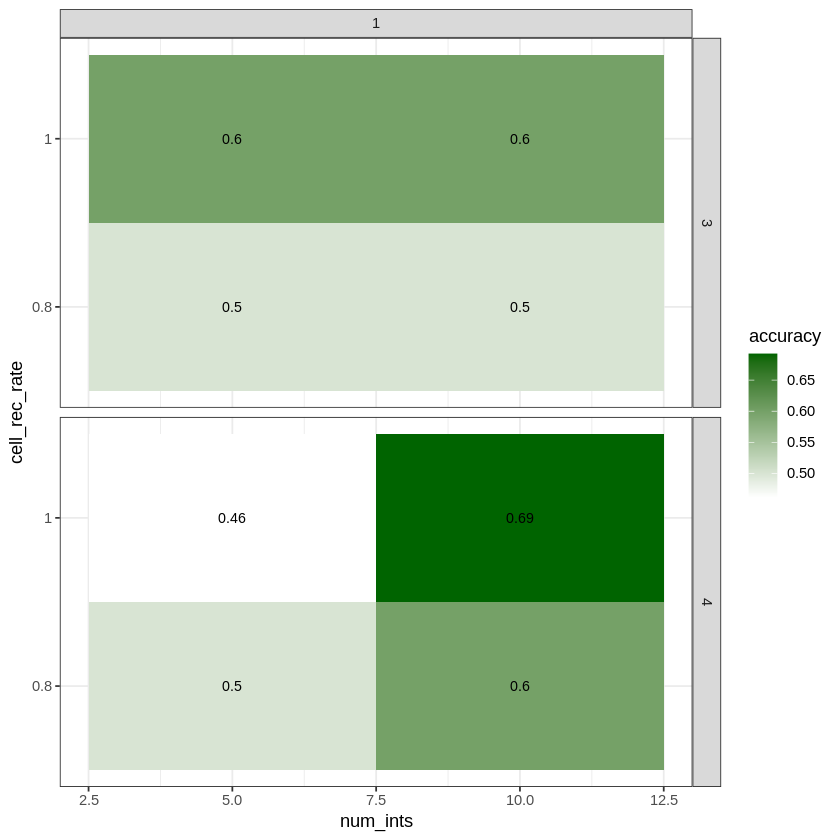

In [80]:
res_8238399424377 <- make_results_df(8238399424377)
ggplot(res_8238399424377, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(timepoint ~ int_recovery_prob)  # Facet by Group1 (rows) and Group2 (columns)

In [ ]:
# first line of each txt file has the rf dist
# second line has the path to the parameter file used


In [ ]:
# extract bc/mt, num_ints, integration recovery prob, cell recovery rate, and timepoint from the name of the file (since these vary in the param file)


In [31]:
(current_timepoint <- str_extract('processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                 '(?<=_time_)[0-9.]+'))
(bc_or_mt <- str_extract(string = 'processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                        pattern = '(?<=processed_)(mt|bc)(?=_list)'))
(num_ints <- as.integer(str_extract(string = 'processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                           pattern = '(?<=_list_)\\d+')))
(cell_rec_rate <- str_extract('processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                 '(?<=_cell_rec_rate_)[0-9.]+'))
(int_recovery_prob <- str_extract('processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                 '(?<=_recovery_prob_)[0-9.]+'))



[1] "3"

[1] "bc"

[1] 10

[1] "0.8"

[1] "1"

In [32]:
sub_df <- data.frame('timepoint' = current_timepoint, 
                     'bc_or_mt' = bc_or_mt,
                     'num_ints' = num_ints,
                     'cell_rec_rate' = cell_rec_rate,
                     'int_recovery_prob' = int_recovery_prob)

In [33]:
sub_df

timepoint,bc_or_mt,num_ints,cell_rec_rate,int_recovery_prob
<chr>,<chr>,<int>,<chr>,<chr>
3,bc,10,0.8,1


In [5]:
current_timepoint

[1] "3"